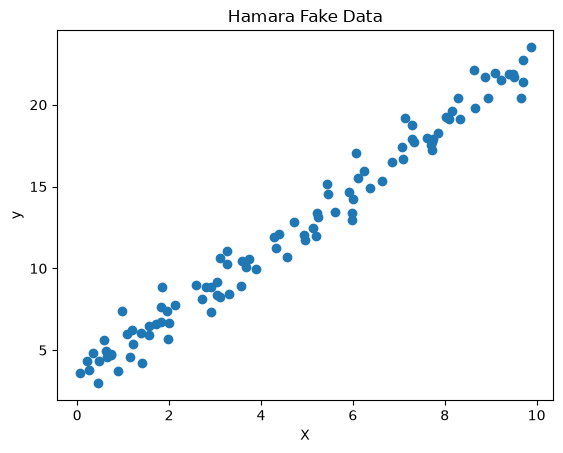

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Fake data banate hain (y = 2x + 3 ke around, thoda noise ke saath)
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 random numbers 0-10 ke beech
y = 2 * X + 3 + np.random.randn(100, 1)  # y = 2x + 3 + thoda random noise

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Hamara Fake Data')
plt.show()

In [23]:
m = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(X)

for i in range(epochs):
    y_pred = m * X + b
    
    error = y - y_pred
    cost = np.mean(error ** 2)
    
    dm = -(2/n) * np.sum(X * error)
    db = -(2/n) * np.sum(error)
    
    m = m - learning_rate * dm
    b = b - learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}: Cost = {cost:.4f}, m = {m:.4f}, b = {b:.4f}")

print(f"\nFinal: m = {m:.4f}, b = {b:.4f}")
print("Actual tha: m = 2, b = 3")

Epoch 0: Cost = 188.0826, m = 1.5087, b = 0.2481
Epoch 100: Cost = 1.5633, m = 2.2036, b = 1.5915
Epoch 200: Cost = 1.0554, m = 2.0971, b = 2.2842
Epoch 300: Cost = 0.8884, m = 2.0361, b = 2.6813
Epoch 400: Cost = 0.8335, m = 2.0011, b = 2.9090
Epoch 500: Cost = 0.8154, m = 1.9810, b = 3.0396
Epoch 600: Cost = 0.8095, m = 1.9695, b = 3.1145
Epoch 700: Cost = 0.8075, m = 1.9629, b = 3.1574
Epoch 800: Cost = 0.8069, m = 1.9591, b = 3.1820
Epoch 900: Cost = 0.8067, m = 1.9569, b = 3.1961

Final: m = 1.9557, b = 3.2042
Actual tha: m = 2, b = 3


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("sklearn se m:", model.coef_[0][0])
print("sklearn se b:", model.intercept_[0])

sklearn se m: 1.9540226772876963
sklearn se b: 3.21509615754675


In [25]:
from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X, y)
print("Ridge (L2) - m:", ridge_model.coef_.flatten()[0])
print("Ridge (L2) - b:", ridge_model.intercept_.flatten()[0])

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X, y)
print("Lasso (L1) - m:", lasso_model.coef_.flatten()[0])
print("Lasso (L1) - b:", lasso_model.intercept_.flatten()[0])

Ridge (L2) - m: 1.9517949810129913
Ridge (L2) - b: 3.2255703564513674
Lasso (L1) - m: 1.839886905017725
Lasso (L1) - b: 3.751740580066162


In [26]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('Titanic-Dataset.csv')
df['Age'] = df['Age'].fillna(df['Age'].mean())
df = df.drop(columns=['Cabin'], errors='ignore')
df = df.dropna()
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X_titanic = df[['Pclass', 'Sex', 'Age', 'Fare']]
y_titanic = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

predictions = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, predictions))

Decision Tree Accuracy: 0.8146067415730337
